In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (10, 5)
print("Ready. pandas:", pd.__version__)

Ready. pandas: 2.3.3


In [2]:
DATA_DIR = '../Data/'

tables = {
    'orders': pd.read_csv(DATA_DIR + 'olist_orders_dataset.csv'),
    'items': pd.read_csv(DATA_DIR + 'olist_order_items_dataset.csv'),
    'reviews': pd.read_csv(DATA_DIR + 'olist_order_reviews_dataset.csv'),
    'products': pd.read_csv(DATA_DIR + 'olist_products_dataset.csv'),
    'cat_xlat': pd.read_csv(DATA_DIR + 'product_category_name_translation.csv'),
    'sellers': pd.read_csv(DATA_DIR + 'olist_sellers_dataset.csv'),
}

for name, df in tables.items():
    print(f"{name:12} {df.shape[0]:>7,} rows × {df.shape[1]} cols")

orders        99,441 rows × 8 cols
items        112,650 rows × 7 cols
reviews       99,224 rows × 7 cols
products      32,951 rows × 9 cols
cat_xlat          71 rows × 2 cols
sellers        3,095 rows × 4 cols


In [3]:
r = tables['reviews']
print("Review score distribution:")
print(r['review_score'].value_counts().sort_index())
print(f"\nPct of bad reviews (≤2★): {(r['review_score'] <= 2).mean() * 100:.1f}%")

Review score distribution:
review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64

Pct of bad reviews (≤2★): 14.7%


In [4]:
orders = tables['orders'].copy()

# Convert date columns to actual datetimes (they're strings right now)
date_cols = ['order_purchase_timestamp', 'order_approved_at',
             'order_delivered_carrier_date', 'order_delivered_customer_date',
             'order_estimated_delivery_date']
for c in date_cols:
    orders[c] = pd.to_datetime(orders[c])

# Keep only orders that were actually delivered (otherwise delivery features are null)
orders = orders[orders['order_status'] == 'delivered'].dropna(
    subset=['order_delivered_customer_date']
)

# Engineered features
orders['delivery_time_days'] = (
    orders['order_delivered_customer_date'] - orders['order_purchase_timestamp']
).dt.days
orders['delivery_delay_days'] = (
    orders['order_delivered_customer_date'] - orders['order_estimated_delivery_date']
).dt.days   # positive = late, negative = early

print(f"Delivered orders: {len(orders):,}")
print(f"Avg delivery time: {orders['delivery_time_days'].mean():.1f} days")
print(f"Avg delay vs estimate: {orders['delivery_delay_days'].mean():.1f} days (negative = early)")

Delivered orders: 96,470
Avg delivery time: 12.1 days
Avg delay vs estimate: -11.9 days (negative = early)


In [5]:
items = tables['items']
items_agg = items.groupby('order_id').agg(
    n_items=('order_item_id', 'count'),
    total_price=('price', 'sum'),
    total_freight=('freight_value', 'sum'),
    primary_seller=('seller_id', 'first'),
    primary_product=('product_id', 'first'),
).reset_index()
items_agg['freight_pct'] = items_agg['total_freight'] / items_agg['total_price']

print(f"Items rolled up to {len(items_agg):,} orders")
items_agg.head()

Items rolled up to 98,666 orders


,order_id,n_items,total_price,total_freight,primary_seller,primary_product,freight_pct
0,00010242fe8c5a6d1ba2dd792cb16214,1,58.90,13.29,48436dade18ac8b2bce089ec2a041202,4244733e06e7ecb4970a6e2683c13e61,0.225637
1,00018f77f2f0320c557190d7a144bdd3,1,239.90,19.93,dd7ddc04e1b6c2c614352b383efe2d36,e5f2d52b802189ee658865ca93d83a8f,0.083076
2,000229ec398224ef6ca0657da4fc703e,1,199.00,17.87,5b51032eddd242adc84c38acab88f23d,c777355d18b72b67abbeef9df44fd0fd,0.089799
3,00024acbcdf0a6daa1e931b038114c75,1,12.99,12.79,9d7a1d34a5052409006425275ba1c2b4,7634da152a4610f1595efa32f14722fc,0.984604
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,199.90,18.14,df560393f3a51e74553ab94004ba5c87,ac6c3623068f30de03045865e4e10089,0.090745


In [6]:
reviews = tables['reviews']
reviews_agg = reviews.groupby('order_id').agg(
    review_score=('review_score', 'mean'),
    n_reviews=('review_id', 'count'),
).reset_index()
reviews_agg['review_score_round'] = reviews_agg['review_score'].round().astype(int)

print(f"Reviews rolled up to {len(reviews_agg):,} orders")
reviews_agg.head()

Reviews rolled up to 98,673 orders


,order_id,review_score,n_reviews,review_score_round
0,00010242fe8c5a6d1ba2dd792cb16214,5.0,1,5
1,00018f77f2f0320c557190d7a144bdd3,4.0,1,4
2,000229ec398224ef6ca0657da4fc703e,5.0,1,5
3,00024acbcdf0a6daa1e931b038114c75,4.0,1,4
4,00042b26cf59d7ce69dfabb4e55b4fd9,5.0,1,5


In [7]:
products = tables['products'][['product_id', 'product_category_name']]
cat_xlat = tables['cat_xlat']
sellers = tables['sellers'][['seller_id', 'seller_state']]

df = (orders
      .merge(items_agg, on='order_id', how='left')
      .merge(reviews_agg, on='order_id', how='left')
      .merge(products, left_on='primary_product', right_on='product_id', how='left')
      .merge(cat_xlat, on='product_category_name', how='left')
      .merge(sellers, left_on='primary_seller', right_on='seller_id', how='left')
)

# Drop orders missing critical pieces
df = df.dropna(subset=['review_score', 'total_price', 'product_category_name_english'])

# Bad review flag (our target)
df['is_bad_review'] = (df['review_score_round'] <= 2).astype(int)

print(f"Master dataframe: {df.shape[0]:,} orders × {df.shape[1]} cols")
print(f"% bad reviews in cleaned data: {df['is_bad_review'].mean() * 100:.1f}%")

cols_to_show = ['order_id', 'review_score_round', 'is_bad_review',
                'product_category_name_english', 'total_price',
                'delivery_delay_days', 'seller_state']
df[cols_to_show].head()

Master dataframe: 94,455 orders × 25 cols
% bad reviews in cleaned data: 12.7%


,order_id,review_score_round,is_bad_review,product_category_name_english,total_price,delivery_delay_days,seller_state
0,e481f51cbdc54678b7cc49136f2d6af7,4.0,0,housewares,29.99,-8,SP
1,53cdb2fc8bc7dce0b6741e2150273451,4.0,0,perfumery,118.70,-6,SP
2,47770eb9100c2d0c44946d9cf07ec65d,5.0,0,auto,159.90,-18,SP
3,949d5b44dbf5de918fe9c16f97b45f8a,5.0,0,pet_shop,45.00,-13,MG
4,ad21c59c0840e6cb83a9ceb5573f8159,5.0,0,stationery,19.90,-10,SP


In [8]:
# Bucket delivery delays into intuitive groups
df['delivery_bucket'] = pd.cut(
    df['delivery_delay_days'],
    bins=[-100, -7, -1, 0, 7, 100],
    labels=['7+ days early', '1-7 days early', 'on time', '1-7 days late', '7+ days late']
)

overall = df['is_bad_review'].mean()
print(f"Overall bad review rate: {overall*100:.1f}%\n")

print("=== Bad review rate by delivery performance ===")
print(df.groupby('delivery_bucket', observed=True)['is_bad_review']
        .agg(['mean', 'count']).round(3))

print("\n=== Top 10 worst categories (min 500 orders) ===")
cat_summary = (df.groupby('product_category_name_english')
                 .agg(bad_rate=('is_bad_review', 'mean'),
                      n_orders=('is_bad_review', 'count'))
                 .query('n_orders >= 500')
                 .sort_values('bad_rate', ascending=False))
print(cat_summary.head(10).round(3).to_string())

print("\n=== 5 best categories (lowest bad rate) ===")
print(cat_summary.tail(5).round(3).to_string())

Overall bad review rate: 12.7%

=== Bad review rate by delivery performance ===
                  mean  count
delivery_bucket              
7+ days early    0.089  74665
1-7 days early   0.105  12244
on time          0.122   1257
1-7 days late    0.493   3544
7+ days late     0.798   2704

=== Top 10 worst categories (min 500 orders) ===
                                 bad_rate  n_orders
product_category_name_english                      
office_furniture                    0.220      1236
bed_bath_table                      0.157      9072
furniture_decor                     0.150      6167
computers_accessories               0.145      6469
telephony                           0.140      4052
baby                                0.138      2741
watches_gifts                       0.135      5430
construction_tools_construction     0.131       723
electronics                         0.131      2488
auto                                0.129      3774

=== 5 best categories (lowest bad r

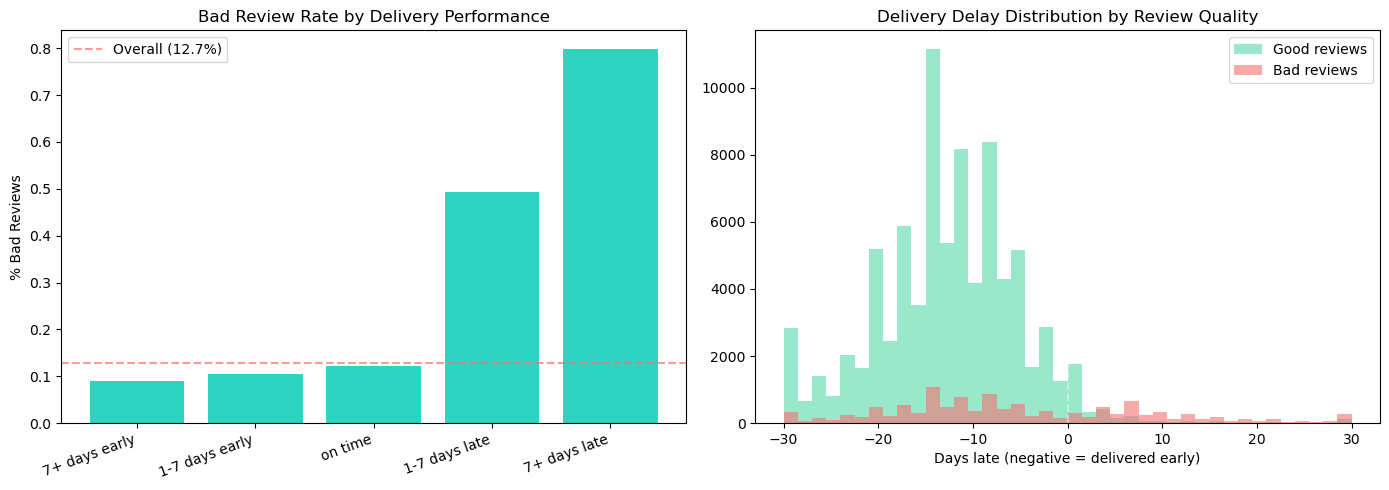

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: bar chart of bad rate by delivery bucket
delivery_rates = df.groupby('delivery_bucket', observed=True)['is_bad_review'].mean()
axes[0].bar(delivery_rates.index.astype(str), delivery_rates.values,
            color='#2DD4BF', edgecolor='none')
axes[0].axhline(overall, color='#F87171', linestyle='--', alpha=0.7,
                label=f'Overall ({overall*100:.1f}%)')
axes[0].set_title('Bad Review Rate by Delivery Performance', fontsize=12)
axes[0].set_ylabel('% Bad Reviews')
axes[0].legend()
plt.setp(axes[0].get_xticklabels(), rotation=20, ha='right')

# Right: delivery delay distribution, split by good vs bad
delay_clipped = df['delivery_delay_days'].clip(-30, 30)
axes[1].hist(delay_clipped[df['is_bad_review']==0], bins=40, alpha=0.5,
             label='Good reviews', color='#34D399')
axes[1].hist(delay_clipped[df['is_bad_review']==1], bins=40, alpha=0.6,
             label='Bad reviews', color='#F87171')
axes[1].axvline(0, color='white', linestyle='--', alpha=0.4)
axes[1].set_title('Delivery Delay Distribution by Review Quality', fontsize=12)
axes[1].set_xlabel('Days late (negative = delivered early)')
axes[1].legend()

plt.tight_layout()
plt.show()

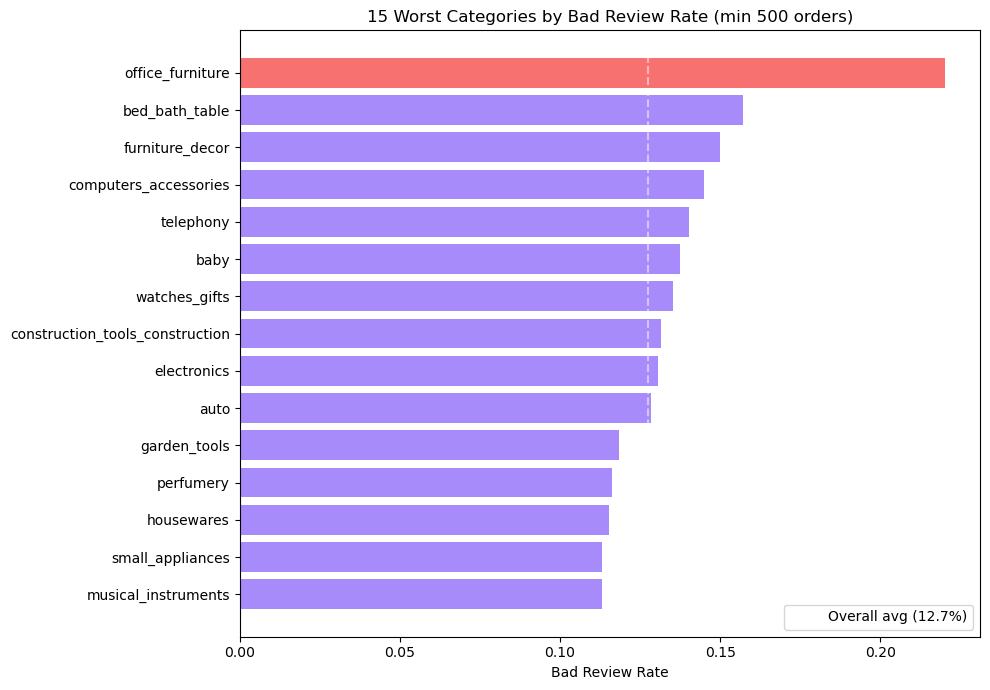

In [10]:
top_bad = cat_summary.head(15).sort_values('bad_rate')

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#F87171' if r > overall * 1.5 else '#A78BFA' for r in top_bad['bad_rate']]
ax.barh(top_bad.index, top_bad['bad_rate'], color=colors, edgecolor='none')
ax.axvline(overall, color='white', linestyle='--', alpha=0.5,
           label=f'Overall avg ({overall*100:.1f}%)')
ax.set_xlabel('Bad Review Rate')
ax.set_title('15 Worst Categories by Bad Review Rate (min 500 orders)', fontsize=12)
ax.legend()
plt.tight_layout()
plt.show()

In [11]:
state_summary = (df.groupby('seller_state')
                   .agg(bad_rate=('is_bad_review', 'mean'),
                        n_orders=('is_bad_review', 'count'),
                        avg_delivery_days=('delivery_time_days', 'mean'))
                   .query('n_orders >= 500')
                   .sort_values('bad_rate', ascending=False))
print("Bad review rate by seller state (min 500 orders):")
print(state_summary.round(3).to_string())

Bad review rate by seller state (min 500 orders):
              bad_rate  n_orders  avg_delivery_days
seller_state                                       
DF               0.141       793             11.987
SP               0.133     66953             11.851
SC               0.122      3515             13.247
PR               0.121      7331             12.949
RJ               0.118      4082             11.583
BA               0.110       547             13.402
MG               0.106      7429             12.346
RS               0.086      1894             11.092
